# Power Flow Methods — Gauss–Seidel · Newton–Raphson · Fast Decoupled

This notebook solves the AC **power-flow (load-flow) problem** on a small 3-bus test
system using the three classic iterative methods taught in power-systems courses:

1. **Gauss–Seidel (GS)**
2. **Newton–Raphson (NR)**
3. **Fast Decoupled (FD)**

For each method the notebook computes the bus voltages, the bus power injections,
the branch currents and power flows, the transmission-line losses, and a power-balance
check. It also plots how the voltages and the mismatches converge over the iterations.

## The power-flow problem

Given the network admittance matrix $Y_{bus}$ and the scheduled power at each bus,
we look for the complex voltage $V_i = |V_i|\angle\delta_i$ at every bus such that the
injected power matches the schedule. The injected complex power at bus $i$ is

$$ S_i = V_i \left(\sum_{j} Y_{ij} V_j\right)^{*}. $$

Buses are classified as **Slack** (voltage fixed, angle reference), **PV** (real power
and voltage magnitude known) or **PQ** (real and reactive power known).

## Test system

All quantities are in **per unit (pu)**.

| Bus | Type  | Known quantities            |
|-----|-------|-----------------------------|
| 1   | Slack | $|V| = 1.05$, $\delta = 0$  |
| 2   | PQ    | $P = -2.566$, $Q = -1.102$  |
| 3   | PQ    | $P = -1.386$, $Q = -0.452$  |

All three methods converge to the same solution
$V \approx [\,1.05,\; 0.982\angle{-3.5^\circ},\; 1.001\angle{-2.9^\circ}\,]$,
which is a good consistency check.

## Requirements

```
numpy   sympy   matplotlib
```

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

%matplotlib inline
np.set_printoptions(precision=4, suppress=True)

## System data and shared helpers

The cell below defines the test system once and a small set of helper functions that
are reused by the three methods (so the post-processing is written only once):

- `bus_power` — complex power injected at every bus.
- `pq_polar` — active/reactive injections from the polar bus equations (used by NR and FD).
- `branch_flows` — branch currents, branch power flows and line losses.
- `report` — prints the full result set for a solved case.
- `plot_voltage` / `plot_error` — convergence plots.

In [2]:
# =====================================================================
# Test system  (shared by the three methods)
# =====================================================================
# 3-bus network. All quantities are in per unit (pu).
#
#   Bus 1 -> Slack (reference): |V| and angle fixed.
#   Bus 2 -> PQ  : P and Q specified (a load).
#   Bus 3 -> PQ  : P and Q specified (a load).
#
# Bus indices are 0-based internally (bus 1 -> index 0).

Ybus = np.array([[20 - 50j, -10 + 20j, -10 + 30j],
                 [-10 + 20j, 26 - 52j, -16 + 32j],
                 [-10 + 30j, -16 + 32j, 26 - 62j]])

P_sch = np.array([0.0, -2.566, -1.386])   # scheduled real power injection
Q_sch = np.array([0.0, -1.102, -0.452])   # scheduled reactive power injection

slack = [0]        # slack buses
pv    = []         # voltage-controlled (PV) buses
pq    = [1, 2]     # load (PQ) buses

V_flat = np.array([1.05, 1.0, 1.0])       # initial voltage magnitudes (slack = 1.05)

n = Ybus.shape[0]                         # number of buses
Ymag, Yang = np.abs(Ybus), np.angle(Ybus)  # |Y_ij| and theta_ij (polar admittance)


# =====================================================================
# Shared helper functions
# =====================================================================
def bus_power(V):
    """Complex power injected at every bus: S_i = V_i * conj( sum_j Y_ij V_j )."""
    return V * np.conj(Ybus @ V)


def pq_polar(Vmag, delta):
    """Real and reactive power injections from the polar form of the bus equations.

        P_i =  sum_j |V_i||V_j||Y_ij| cos(theta_ij - d_i + d_j)
        Q_i = -sum_j |V_i||V_j||Y_ij| sin(theta_ij - d_i + d_j)
    """
    ang = Yang - delta[:, None] + delta[None, :]
    P = Vmag * ((Ymag * np.cos(ang)) @ Vmag)
    Q = -Vmag * ((Ymag * np.sin(ang)) @ Vmag)
    return P, Q


def branch_flows(V):
    """Branch currents, complex power flows and line losses (off-diagonal, i != j)."""
    I = Ybus * (V[:, None] - V[None, :])
    np.fill_diagonal(I, 0)
    S_ij = V[:, None] * np.conj(I)
    losses = S_ij + S_ij.T
    return I, S_ij, losses


def report(name, V, iterations):
    """Print the full result set for a solved case."""
    S = bus_power(V)
    I, S_ij, losses = branch_flows(V)
    line = "=" * (len(name) + 14)
    print(f"{line}\n===== {name} =====\n{line}")
    print(f"Converged in {iterations} iterations\n")
    print("Bus voltages  |V|  (pu):", np.abs(V))
    print("Bus angles         (rad):", np.angle(V))
    print("Bus voltages (rectangular):", V)
    print("Bus power injections S=P+jQ (pu):", S)
    print("\nBranch currents (pu):\n", I)
    print("\nBranch power flows S_ij (pu):\n", S_ij)
    print("\nLine losses (pu):\n", losses)
    print("\nPower balance per bus (injection + outgoing flows, should be ~0):")
    for i in range(n):
        mismatch = S[i] + S_ij[i].sum()
        print(f"   Bus {i + 1}: {mismatch:.2e}")


def plot_voltage(vmag_hist, method):
    """Voltage magnitude of every bus across the iterations."""
    it = np.arange(1, len(vmag_hist) + 1)
    colors = plt.cm.viridis(np.linspace(0, 1, n))
    plt.figure(figsize=(7, 4))
    for i in range(n):
        plt.plot(it, np.array(vmag_hist)[:, i], marker='o', color=colors[i], label=f'Bus {i + 1}')
    plt.xlabel('Iteration'); plt.ylabel('|V| (pu)')
    plt.title(f'{method} - voltage magnitude per iteration')
    plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


def plot_error(err_hist, labels, tol, method, ylabel):
    """Convergence of a set of error/mismatch quantities (log scale)."""
    it = np.arange(1, len(err_hist) + 1)
    arr = np.abs(np.array(err_hist, dtype=float))
    colors = plt.cm.viridis(np.linspace(0, 1, len(labels)))
    plt.figure(figsize=(7, 4))
    for k, lab in enumerate(labels):
        plt.plot(it, arr[:, k], marker='o', color=colors[k], label=lab)
    plt.axhline(tol, color='r', linestyle='--', label='Tolerance')
    plt.yscale('log')
    plt.xlabel('Iteration'); plt.ylabel(ylabel)
    plt.title(f'{method} - {ylabel} per iteration')
    plt.grid(True, which='both'); plt.legend(); plt.tight_layout(); plt.show()

## 1. Gauss–Seidel

The Gauss–Seidel method rearranges the nodal equation $\sum_j Y_{ij} V_j = S_i^{*}/V_i^{*}$
to solve for each voltage and sweeps through the buses, immediately reusing the freshly
updated values:

$$ V_i = \frac{1}{Y_{ii}}\left(\frac{P_i - jQ_i}{V_i^{*}} - \sum_{j\ne i} Y_{ij}\,V_j\right). $$

Per bus type:

- **Slack** — voltage held constant.
- **PV** — the reactive power $Q_i$ is unknown, so it is recomputed each sweep from the
  latest voltages; after updating $V_i$ its magnitude is forced back to the scheduled value.
- **PQ** — the equation above is applied directly.

Iteration stops when the real and imaginary parts of every voltage change by less than the
tolerance. It is the simplest method but converges linearly (the most iterations here).

===== GAUSS-SEIDEL =====
Converged in 10 iterations

Bus voltages  |V|  (pu): [1.05   0.9818 1.0013]
Bus angles         (rad): [ 0.     -0.0611 -0.05  ]
Bus voltages (rectangular): [1.05+0.j   0.98-0.06j 1.  -0.05j]
Bus power injections S=P+jQ (pu): [ 4.0949+1.89j  -2.5659-1.102j -1.386 -0.452j]

Branch currents (pu):
 [[ 0.  +0.j   -1.9 +0.8j  -2.  +1.j  ]
 [ 1.9 -0.8j   0.  +0.j    0.64-0.48j]
 [ 2.  -1.j   -0.64+0.48j  0.  +0.j  ]]

Branch power flows S_ij (pu):
 [[ 0.   +0.j    -1.995-0.84j  -2.1  -1.05j ]
 [ 1.91 +0.67j   0.   -0.j     0.656+0.432j]
 [ 2.05 +0.9j   -0.664-0.448j  0.   -0.j   ]]

Line losses (pu):
 [[ 0.   +0.j    -0.085-0.17j  -0.05 -0.15j ]
 [-0.085-0.17j   0.   -0.j    -0.008-0.016j]
 [-0.05 -0.15j  -0.008-0.016j  0.   -0.j   ]]

Power balance per bus (injection + outgoing flows, should be ~0):
   Bus 1: -1.78e-15-1.55e-15j
   Bus 2: -8.88e-16+1.11e-15j
   Bus 3: 6.66e-16-3.28e-15j


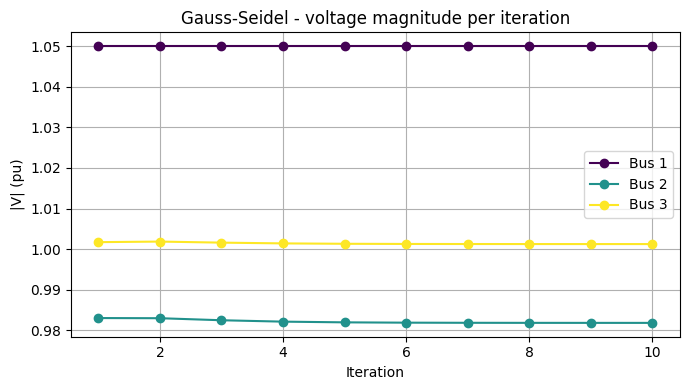

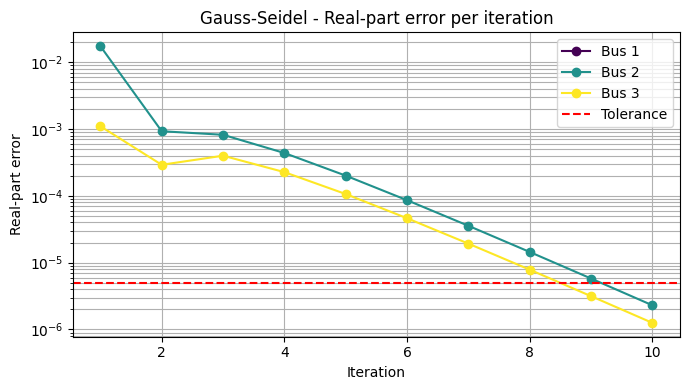

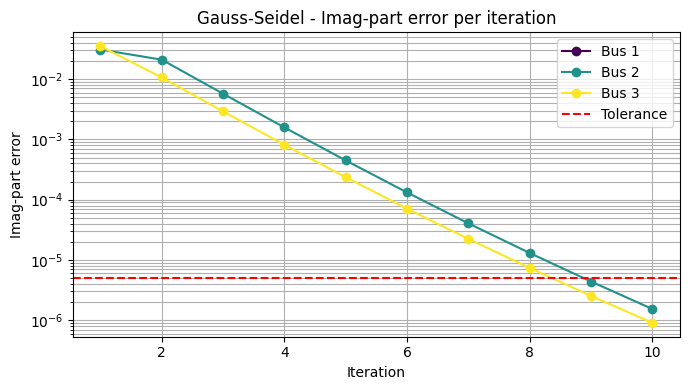

In [3]:
def gauss_seidel(tol=5e-6, max_iter=100):
    """Solve the power flow with the Gauss-Seidel method.

    Each bus voltage is refreshed in place from
        V_i = (1 / Y_ii) * ( (P_i - jQ_i) / conj(V_i) - sum_{j != i} Y_ij V_j ).
    """
    V = V_flat.astype(complex).copy()   # working voltages (updated in place)
    Vset = V_flat.copy()                # scheduled |V| for PV buses
    Q = Q_sch.copy()                    # Q is recomputed on PV buses each sweep

    vmag_hist, err_re_hist, err_im_hist = [], [], []
    for it in range(1, max_iter + 1):
        V_prev = V.copy()
        for b in range(n):
            if b in slack:               # slack voltage stays fixed
                continue
            off = Ybus[b] @ V - Ybus[b, b] * V[b]   # sum_{j != b} Y_bj V_j
            if b in pv:                  # PV bus: reactive power is unknown -> recompute it
                Q[b] = -(np.conj(V[b]) * (Ybus[b] @ V)).imag
            V[b] = (1 / Ybus[b, b]) * ((P_sch[b] - 1j * Q[b]) / np.conj(V[b]) - off)
            if b in pv:                  # enforce the scheduled magnitude on PV buses
                V[b] = complex(np.sqrt(Vset[b] ** 2 - V[b].imag ** 2), V[b].imag)

        vmag_hist.append(np.abs(V).copy())
        err_re_hist.append(np.abs(V.real - V_prev.real))
        err_im_hist.append(np.abs(V.imag - V_prev.imag))
        if np.all(np.abs(V - V_prev) < tol):     # converged on both components
            break

    return V, it, {'vmag': vmag_hist, 'err_re': err_re_hist, 'err_im': err_im_hist}


tol_gs = 5e-6
V_gs, it_gs, hist_gs = gauss_seidel(tol=tol_gs)
report("GAUSS-SEIDEL", V_gs, it_gs)

bus_labels = [f'Bus {i + 1}' for i in range(n)]
plot_voltage(hist_gs['vmag'], 'Gauss-Seidel')
plot_error(hist_gs['err_re'], bus_labels, tol_gs, 'Gauss-Seidel', 'Real-part error')
plot_error(hist_gs['err_im'], bus_labels, tol_gs, 'Gauss-Seidel', 'Imag-part error')

## 2. Newton–Raphson

Newton–Raphson works with the polar form of the injected power,

$$ P_i = \sum_j |V_i||V_j||Y_{ij}|\cos(\theta_{ij} - \delta_i + \delta_j), \qquad
   Q_i = -\sum_j |V_i||V_j||Y_{ij}|\sin(\theta_{ij} - \delta_i + \delta_j), $$

and linearises the power mismatch around the current estimate:

$$ \mathbf{J}\begin{bmatrix}\Delta\boldsymbol{\delta}\\ \Delta|\mathbf{V}|\end{bmatrix}
   = \begin{bmatrix}\Delta \mathbf{P}\\ \Delta \mathbf{Q}\end{bmatrix}. $$

The unknowns are the angles of every non-slack bus and the voltage magnitudes of the PQ
buses. The Jacobian $\mathbf{J}$ is derived **symbolically with SymPy once**, before the
loop, and both the mismatch vector and the Jacobian are compiled to fast numeric functions
with `sp.lambdify`. Each iteration then only evaluates them and solves the linear system.
Newton–Raphson converges quadratically — just a handful of iterations.

===== NEWTON-RAPHSON =====
Converged in 4 iterations

Bus voltages  |V|  (pu): [1.05   0.9818 1.0012]
Bus angles         (rad): [ 0.     -0.0611 -0.05  ]
Bus voltages (rectangular): [1.05+0.j   0.98-0.06j 1.  -0.05j]
Bus power injections S=P+jQ (pu): [ 4.095+1.89j  -2.566-1.102j -1.386-0.452j]

Branch currents (pu):
 [[ 0.  +0.j   -1.9 +0.8j  -2.  +1.j  ]
 [ 1.9 -0.8j   0.  +0.j    0.64-0.48j]
 [ 2.  -1.j   -0.64+0.48j  0.  +0.j  ]]

Branch power flows S_ij (pu):
 [[ 0.   +0.j    -1.995-0.84j  -2.1  -1.05j ]
 [ 1.91 +0.67j   0.   -0.j     0.656+0.432j]
 [ 2.05 +0.9j   -0.664-0.448j  0.   -0.j   ]]

Line losses (pu):
 [[ 0.   +0.j    -0.085-0.17j  -0.05 -0.15j ]
 [-0.085-0.17j   0.   -0.j    -0.008-0.016j]
 [-0.05 -0.15j  -0.008-0.016j  0.   -0.j   ]]

Power balance per bus (injection + outgoing flows, should be ~0):
   Bus 1: -1.78e-15-8.88e-15j
   Bus 2: -1.33e-15-3.33e-15j
   Bus 3: 6.66e-16+4.88e-15j


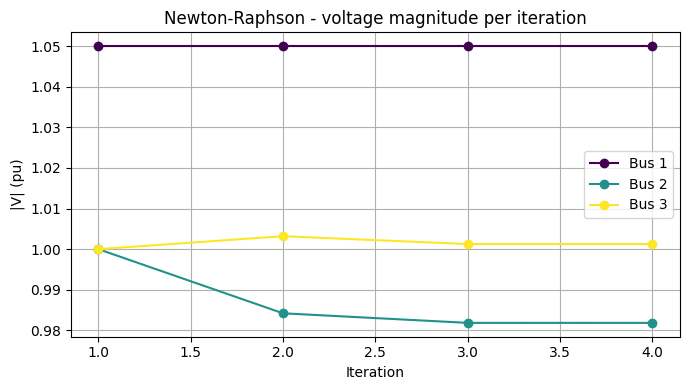

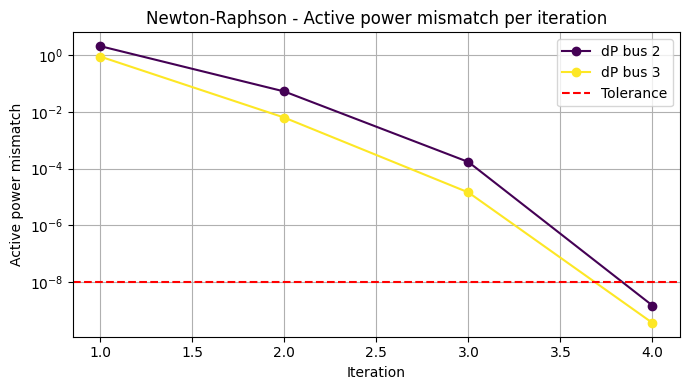

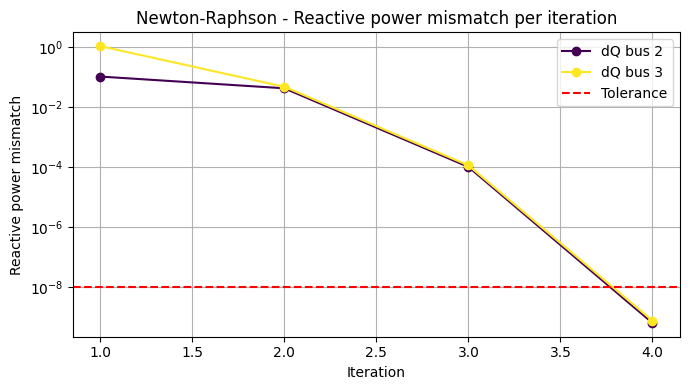

In [4]:
def newton_raphson(tol=1e-8, max_iter=20):
    """Solve the power flow with the Newton-Raphson method.

    The polar power-mismatch equations are built symbolically with SymPy and the
    Jacobian is derived ONCE, outside the loop. Both are turned into fast numeric
    functions with sp.lambdify, so each iteration only evaluates and solves
        J * dx = [dP; dQ].
    """
    Vs = sp.symbols(f'V1:{n + 1}', positive=True)
    ds = sp.symbols(f'd1:{n + 1}', real=True)

    def P_eq(i):
        return sum(Vs[i] * Vs[j] * Ymag[i, j] * sp.cos(Yang[i, j] - ds[i] + ds[j]) for j in range(n))

    def Q_eq(i):
        return -sum(Vs[i] * Vs[j] * Ymag[i, j] * sp.sin(Yang[i, j] - ds[i] + ds[j]) for j in range(n))

    ang_buses = pq + pv        # buses with unknown angle (all non-slack)
    v_buses = pq               # buses with unknown voltage magnitude (PQ only)

    F = sp.Matrix([P_eq(i) for i in ang_buses] + [Q_eq(i) for i in v_buses])
    unknowns = [ds[i] for i in ang_buses] + [Vs[i] for i in v_buses]
    J = F.jacobian(unknowns)

    args = list(ds) + list(Vs)
    F_func = sp.lambdify(args, F, 'numpy')
    J_func = sp.lambdify(args, J, 'numpy')

    Vmag, delta = V_flat.copy(), np.zeros(n)
    n_ang = len(ang_buses)
    P_ref = np.concatenate([P_sch[ang_buses], Q_sch[v_buses]])

    vmag_hist, dP_hist, dQ_hist = [], [], []
    for it in range(1, max_iter + 1):
        vals = list(delta) + list(Vmag)
        F_val = np.array(F_func(*vals), dtype=float).flatten()
        mismatch = P_ref - F_val

        vmag_hist.append(Vmag.copy())
        dP_hist.append(mismatch[:n_ang].copy())
        dQ_hist.append(mismatch[n_ang:].copy())
        if np.max(np.abs(mismatch)) < tol:
            break

        J_val = np.array(J_func(*vals), dtype=float)
        dx = np.linalg.solve(J_val, mismatch)
        delta[ang_buses] += dx[:n_ang]
        Vmag[v_buses] += dx[n_ang:]

    V = Vmag * np.exp(1j * delta)
    return V, it, {'vmag': vmag_hist, 'dP': dP_hist, 'dQ': dQ_hist}


tol_nr = 1e-8
V_nr, it_nr, hist_nr = newton_raphson(tol=tol_nr)
report("NEWTON-RAPHSON", V_nr, it_nr)

labels_P = [f'dP bus {i + 1}' for i in (pq + pv)]
labels_Q = [f'dQ bus {i + 1}' for i in pq]
plot_voltage(hist_nr['vmag'], 'Newton-Raphson')
plot_error(hist_nr['dP'], labels_P, tol_nr, 'Newton-Raphson', 'Active power mismatch')
plot_error(hist_nr['dQ'], labels_Q, tol_nr, 'Newton-Raphson', 'Reactive power mismatch')

## 3. Fast Decoupled

The Fast Decoupled method exploits two properties of transmission networks: active power
is tightly coupled to the bus angles and reactive power to the voltage magnitudes. This
lets us replace the Jacobian with two **constant** matrices — the relevant susceptance
submatrices $B'$ and $B''$ (the imaginary part of $Y_{bus}$) — which are inverted only once:

$$ \Delta\boldsymbol{\delta} = -\,[B']^{-1}\,\frac{\Delta \mathbf{P}}{|\mathbf{V}|}, \qquad
   \Delta|\mathbf{V}| = -\,[B'']^{-1}\,\frac{\Delta \mathbf{Q}}{|\mathbf{V}|}. $$

$B'$ keeps all non-slack buses, $B''$ keeps only the PQ buses. Because the matrices are
constant, each iteration is very cheap; convergence is linear, so it needs more iterations
than Newton–Raphson but each one is much lighter — no Jacobian and no SymPy required.

===== FAST DECOUPLED =====
Converged in 28 iterations

Bus voltages  |V|  (pu): [1.05   0.9818 1.0012]
Bus angles         (rad): [ 0.     -0.0611 -0.05  ]
Bus voltages (rectangular): [1.05+0.j   0.98-0.06j 1.  -0.05j]
Bus power injections S=P+jQ (pu): [ 4.095+1.89j  -2.566-1.102j -1.386-0.452j]

Branch currents (pu):
 [[ 0.  +0.j   -1.9 +0.8j  -2.  +1.j  ]
 [ 1.9 -0.8j   0.  +0.j    0.64-0.48j]
 [ 2.  -1.j   -0.64+0.48j  0.  +0.j  ]]

Branch power flows S_ij (pu):
 [[ 0.   +0.j    -1.995-0.84j  -2.1  -1.05j ]
 [ 1.91 +0.67j   0.   -0.j     0.656+0.432j]
 [ 2.05 +0.9j   -0.664-0.448j  0.   -0.j   ]]

Line losses (pu):
 [[ 0.   +0.j    -0.085-0.17j  -0.05 -0.15j ]
 [-0.085-0.17j   0.   -0.j    -0.008-0.016j]
 [-0.05 -0.15j  -0.008-0.016j  0.   -0.j   ]]

Power balance per bus (injection + outgoing flows, should be ~0):
   Bus 1: -8.88e-16-8.88e-16j
   Bus 2: 1.78e-15+1.78e-15j
   Bus 3: -1.11e-15-1.11e-15j


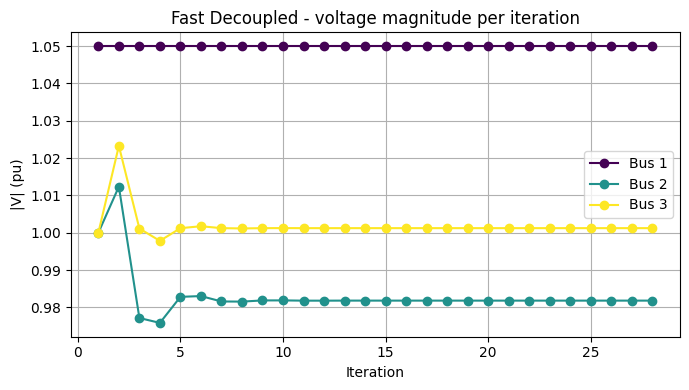

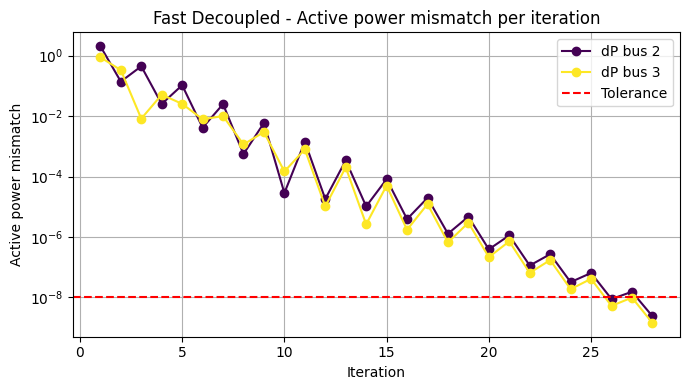

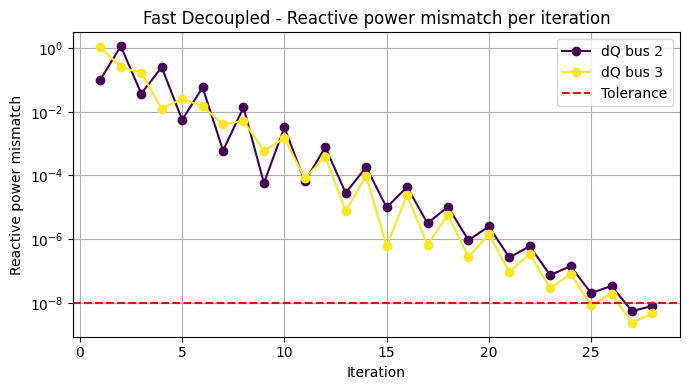

In [5]:
def fast_decoupled(tol=1e-8, max_iter=100):
    """Solve the power flow with the Fast Decoupled method.

    P-d and Q-|V| are decoupled and use the constant, precomputed susceptance
    submatrices B' and B'' (imaginary part of Ybus):
        d|delta| = -[B']^-1 * (dP / |V|)
        d|V|     = -[B'']^-1 * (dQ / |V|)
    Mismatches are evaluated directly from the polar equations (no SymPy needed).
    """
    ang_buses = pq + pv        # angle unknowns (all non-slack)
    v_buses = pq               # magnitude unknowns (PQ only)

    B1 = Ybus.imag[np.ix_(ang_buses, ang_buses)]
    B2 = Ybus.imag[np.ix_(v_buses, v_buses)]
    B1_inv, B2_inv = np.linalg.inv(B1), np.linalg.inv(B2)   # constant across iterations

    Vmag, delta = V_flat.copy(), np.zeros(n)
    vmag_hist, dP_hist, dQ_hist = [], [], []
    for it in range(1, max_iter + 1):
        P, Q = pq_polar(Vmag, delta)
        dP = P_sch[ang_buses] - P[ang_buses]
        dQ = Q_sch[v_buses] - Q[v_buses]

        vmag_hist.append(Vmag.copy())
        dP_hist.append(dP.copy())
        dQ_hist.append(dQ.copy())
        if max(np.max(np.abs(dP)), np.max(np.abs(dQ))) < tol:
            break

        delta[ang_buses] += -B1_inv @ (dP / Vmag[ang_buses])
        Vmag[v_buses] += -B2_inv @ (dQ / Vmag[v_buses])

    V = Vmag * np.exp(1j * delta)
    return V, it, {'vmag': vmag_hist, 'dP': dP_hist, 'dQ': dQ_hist}


tol_fd = 1e-8
V_fd, it_fd, hist_fd = fast_decoupled(tol=tol_fd)
report("FAST DECOUPLED", V_fd, it_fd)

labels_P = [f'dP bus {i + 1}' for i in (pq + pv)]
labels_Q = [f'dQ bus {i + 1}' for i in pq]
plot_voltage(hist_fd['vmag'], 'Fast Decoupled')
plot_error(hist_fd['dP'], labels_P, tol_fd, 'Fast Decoupled', 'Active power mismatch')
plot_error(hist_fd['dQ'], labels_Q, tol_fd, 'Fast Decoupled', 'Reactive power mismatch')